<a href="https://colab.research.google.com/github/joao-victor-g-dev/analise-ids-cicids2017/blob/main/Minera%C3%A7%C3%A3o_DataSet_CIC_IDS_2017_TER%C3%87A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MÓDULO 01: MONTAGEM DO DRIVE E EXTRAÇÃO

In [ ]:
# ==========================================
# MÓDULO 01: MONTAGEM DO DRIVE E EXTRAÇÃO
# ==========================================
from google.colab import drive
import os
import zipfile

# 1. Montar o Google Drive
drive.mount('/content/drive')

# 2. Caminhos do diretório
zip_path = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/CSV/MachineLearningCSV.zip'
extract_path = '/content/dataset_csv'

print("🔍 Verificando integridade dos dados locais...")

# 3. Verificação Inteligente: Checa se a pasta tem arquivos CSV dentro
precisa_extrair = True
if os.path.exists(extract_path):
    # Conta quantos arquivos .csv existem em toda a árvore da pasta
    csv_encontrados = sum(1 for _, _, files in os.walk(extract_path) for f in files if f.endswith('.csv'))
    if csv_encontrados > 0:
        precisa_extrair = False
        print(f"✅ Diretório íntegro! Foram encontrados {csv_encontrados} arquivos CSV. Extração pulada.")
    else:
        print("⚠️ A pasta existe, mas está VAZIA. Forçando nova extração...")

# 4. Extração (se necessária)
if precisa_extrair:
    os.makedirs(extract_path, exist_ok=True)
    print("⏳ Iniciando a extração do ZIP (isso pode levar de 1 a 3 minutos)...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Dataset extraído com sucesso para o armazenamento local!")
    except Exception as e:
        print(f"❌ Erro ao tentar extrair o arquivo: {e}")
        print("Verifique se o caminho do arquivo .zip está 100% correto.")

Mounted at /content/drive
🔍 Verificando integridade dos dados locais...
⏳ Iniciando a extração do ZIP (isso pode levar de 1 a 3 minutos)...
✅ Dataset extraído com sucesso para o armazenamento local!


# MÓDULO 02: ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

🔍 Buscando o arquivo da Terça-feira para Análise Exploratória...
⏳ Carregando dados (Isso pode levar alguns segundos)...
✅ Dados carregados e limpos! Total de instâncias: 445645

🎨 Gerando Painel de Visualização Estatística (Boxplots e Histogramas)...


/tmp/ipykernel_4770/118417762.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='viridis', ax=axes[0], edgecolor='black')
/tmp/ipykernel_4770/118417762.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='Max Packet Length', palette='Set2', ax=axes[1])
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


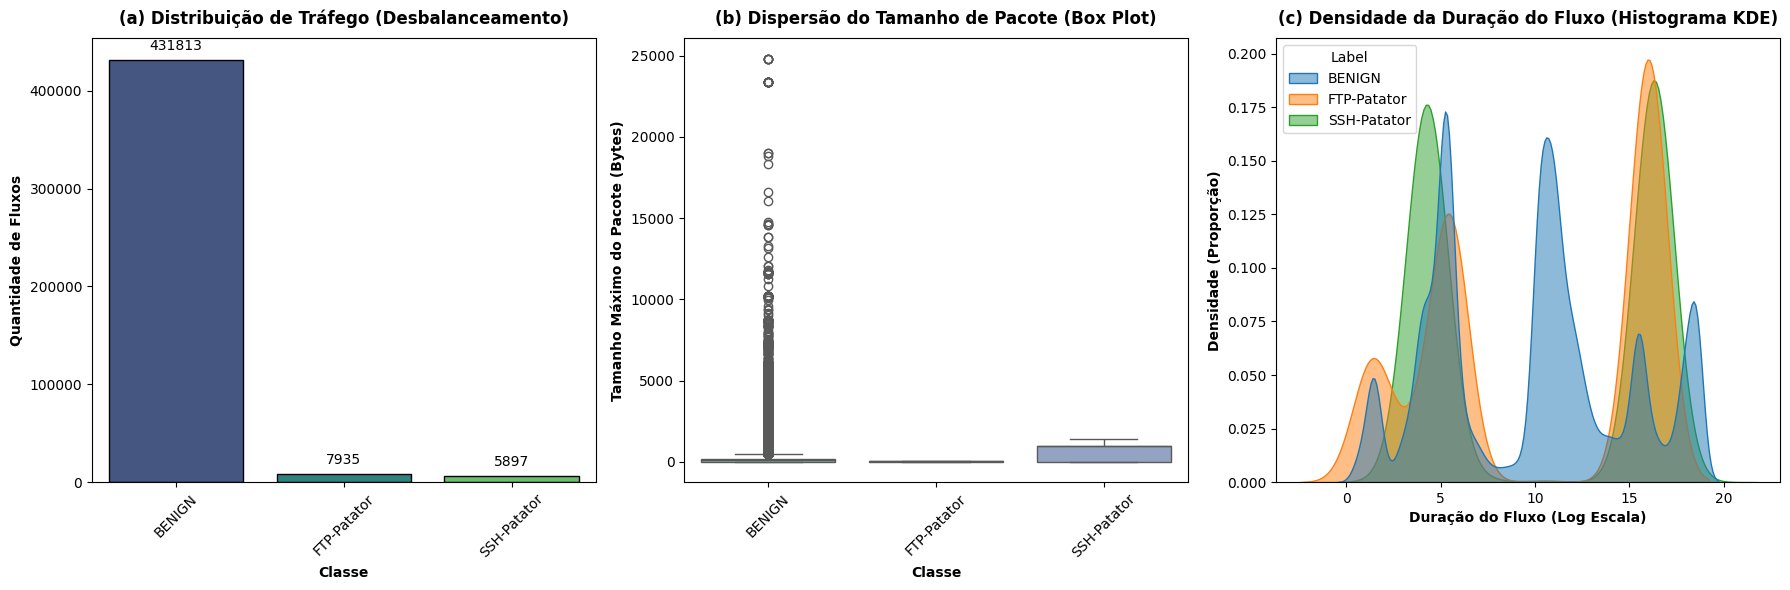

✅ Painel EDA exportado com sucesso para: /content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/EDA/painel_eda_terca.pdf


In [ ]:
# ==========================================
# MÓDULO 02: ANÁLISE EXPLORATÓRIA DE DADOS
#
# ==========================================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Parâmetros
ARQUIVO_ALVO = 'Tuesday-WorkingHours.pcap_ISCX.csv'
EXTRACT_PATH = '/content/dataset_csv'
DIRETORIO_GRAFICOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/EDA'

os.makedirs(DIRETORIO_GRAFICOS, exist_ok=True)

# 2. Busca Inteligente do Arquivo
print("🔍 Buscando o arquivo da Terça-feira para Análise Exploratória...")
CAMINHO_CSV = None
for root, dirs, files in os.walk(EXTRACT_PATH):
    if ARQUIVO_ALVO in files:
        CAMINHO_CSV = os.path.join(root, ARQUIVO_ALVO)
        break

if CAMINHO_CSV is None:
    raise FileNotFoundError(f"🚨 Arquivo {ARQUIVO_ALVO} não encontrado! Verifique a extração.")

# 3. Carregamento e Limpeza Básica
print("⏳ Carregando dados (Isso pode levar alguns segundos)...")
df = pd.read_csv(CAMINHO_CSV)
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"✅ Dados carregados e limpos! Total de instâncias: {len(df)}")

# ==========================================
# GERAÇÃO DO PAINEL VISUAL (IEEE FORMAT)
# ==========================================
print("\n🎨 Gerando Painel de Visualização Estatística (Boxplots e Histogramas)...")
plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Gráfico 1: Distribuição de Classes (Bar Plot) ---
sns.countplot(data=df, x='Label', palette='viridis', ax=axes[0], edgecolor='black')
axes[0].set_title('(a) Distribuição de Tráfego (Desbalanceamento)', fontweight='bold', pad=10)
axes[0].set_ylabel('Quantidade de Fluxos', fontweight='bold')
axes[0].set_xlabel('Classe', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
# Adicionar os números em cima das barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# --- Gráfico 2: Box Plot - Tamanho Máximo do Pacote ---
# O Boxplot é excelente para mostrar anomalias visuais (outliers) entre tráfego normal e ataque
sns.boxplot(data=df, x='Label', y='Max Packet Length', palette='Set2', ax=axes[1])
axes[1].set_title('(b) Dispersão do Tamanho de Pacote (Box Plot)', fontweight='bold', pad=10)
axes[1].set_ylabel('Tamanho Máximo do Pacote (Bytes)', fontweight='bold')
axes[1].set_xlabel('Classe', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# --- Gráfico 3: Histograma (KDE) - Duração do Fluxo ---
# Usamos log scale porque o tempo varia de milissegundos a horas
df['Log_Flow_Duration'] = np.log1p(df['Flow Duration'])
sns.kdeplot(data=df, x='Log_Flow_Duration', hue='Label', fill=True, common_norm=False, palette='tab10', ax=axes[2], alpha=0.5)
axes[2].set_title('(c) Densidade da Duração do Fluxo (Histograma KDE)', fontweight='bold', pad=10)
axes[2].set_ylabel('Densidade (Proporção)', fontweight='bold')
axes[2].set_xlabel('Duração do Fluxo (Log Escala)', fontweight='bold')

plt.tight_layout()

# Exportando para o Drive para usar no Artigo
caminho_painel = os.path.join(DIRETORIO_GRAFICOS, 'painel_eda_terca.pdf')
plt.savefig(caminho_painel, bbox_inches='tight')
plt.show()

print(f"✅ Painel EDA exportado com sucesso para: {caminho_painel}")

# MÓDULO 03: PRÉ-PROCESSAMENTO E ENGENHARIA DE DADOS

In [ ]:
# ==========================================
# MÓDULO 03: PRÉ-PROCESSAMENTO E ENGENHARIA DE DADOS
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import gc
import joblib
import os

DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/Terca_ForcaBruta'
os.makedirs(DIRETORIO_ARTEFATOS, exist_ok=True)

print("1. Removendo colunas temporárias do EDA e isolando features (X) e alvo (y)...")
if 'Log_Flow_Duration' in df.columns:
    df = df.drop(columns=['Log_Flow_Duration'])

X = df.drop(columns=['Label'])
y = df['Label']

# Liberando a RAM do DataFrame original imediatamente
del df
gc.collect()

print("2. Codificando as Classes (Label Encoding)...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
nomes_classes = label_encoder.classes_
print(f"   -> Classes mapeadas: {list(nomes_classes)}")
joblib.dump(label_encoder, os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))

print("3. Dividindo em Treino (70%) e Teste (30%) com estratificação...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Limpando variáveis brutas da memória
del X, y
gc.collect()

print("4. Aplicando Normalização Matemática (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(DIRETORIO_ARTEFATOS, 'scaler.joblib'))

# Limpando variáveis não escaladas da memória
del X_train, X_test
gc.collect()

print("✅ Módulo 03 Concluído! Dados escalonados e prontos para a IA.")

1. Removendo colunas temporárias do EDA e isolando features (X) e alvo (y)...
2. Codificando as Classes (Label Encoding)...
   -> Classes mapeadas: ['BENIGN', 'FTP-Patator', 'SSH-Patator']
3. Dividindo em Treino (70%) e Teste (30%) com estratificação...
4. Aplicando Normalização Matemática (StandardScaler)...
✅ Módulo 03 Concluído! Dados escalonados e prontos para a IA.


# MÓDULO 04-A: TREINAMENTO RANDOM FOREST (BAGGING)

In [ ]:
# ==========================================
# MÓDULO 04-A: TREINAMENTO RANDOM FOREST (BAGGING)
# ==========================================
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/Terca_ForcaBruta'

print("🤖 Iniciando o Treinamento: Random Forest...")

# n_estimators=50 (árvores), max_depth=15 (controle de overfitting)
rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Gerando predições e salvando tudo
y_pred_rf = rf.predict(X_test_scaled)
joblib.dump(rf, os.path.join(DIRETORIO_ARTEFATOS, 'modelo_rf.joblib'))
joblib.dump(y_pred_rf, os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_rf.joblib')) # Salva o resultado para os gráficos

print("✅ Random Forest treinado e salvo com sucesso!")

🤖 Iniciando o Treinamento: Random Forest...
✅ Random Forest treinado e salvo com sucesso!


# MÓDULO 04-B: TREINAMENTO HIST GRADIENT BOOSTING

In [ ]:
# ==========================================
# MÓDULO 04-B: TREINAMENTO HIST GRADIENT BOOSTING
# ==========================================
from sklearn.ensemble import HistGradientBoostingClassifier
import joblib
import os

DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/Terca_ForcaBruta'

print("🤖 Iniciando o Treinamento: HistGradientBoosting...")

# max_iter=100 (iterações), learning_rate=0.1 (tamanho do passo)
hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
hgb.fit(X_train_scaled, y_train)

# Gerando predições e salvando tudo
y_pred_hgb = hgb.predict(X_test_scaled)
joblib.dump(hgb, os.path.join(DIRETORIO_ARTEFATOS, 'modelo_hgb.joblib'))
joblib.dump(y_pred_hgb, os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_hgb.joblib')) # Salva o resultado para os gráficos

print("✅ HistGradientBoosting treinado e salvo com sucesso!")

🤖 Iniciando o Treinamento: HistGradientBoosting...
✅ HistGradientBoosting treinado e salvo com sucesso!


# MÓDULO 05: AVALIAÇÃO DE RESULTADOS E MATRIZES (IEEE)

1. Carregando as predições e os rótulos de teste do Drive...

📊 RELATÓRIO DE CLASSIFICAÇÃO METODOLÓGICA (TERÇA-FEIRA)

--- PERFORMANCE: RANDOM FOREST (BAGGING) ---
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    129544
 FTP-Patator       1.00      1.00      1.00      2381
 SSH-Patator       1.00      1.00      1.00      1769

    accuracy                           1.00    133694
   macro avg       1.00      1.00      1.00    133694
weighted avg       1.00      1.00      1.00    133694


--- PERFORMANCE: HIST GRADIENT BOOSTING (BOOSTING) ---
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    129544
 FTP-Patator       1.00      1.00      1.00      2381
 SSH-Patator       1.00      1.00      1.00      1769

    accuracy                           1.00    133694
   macro avg       1.00      1.00      1.00    133694
weighted avg       1.00      1.00      1.00    133694


2. Renderizando p

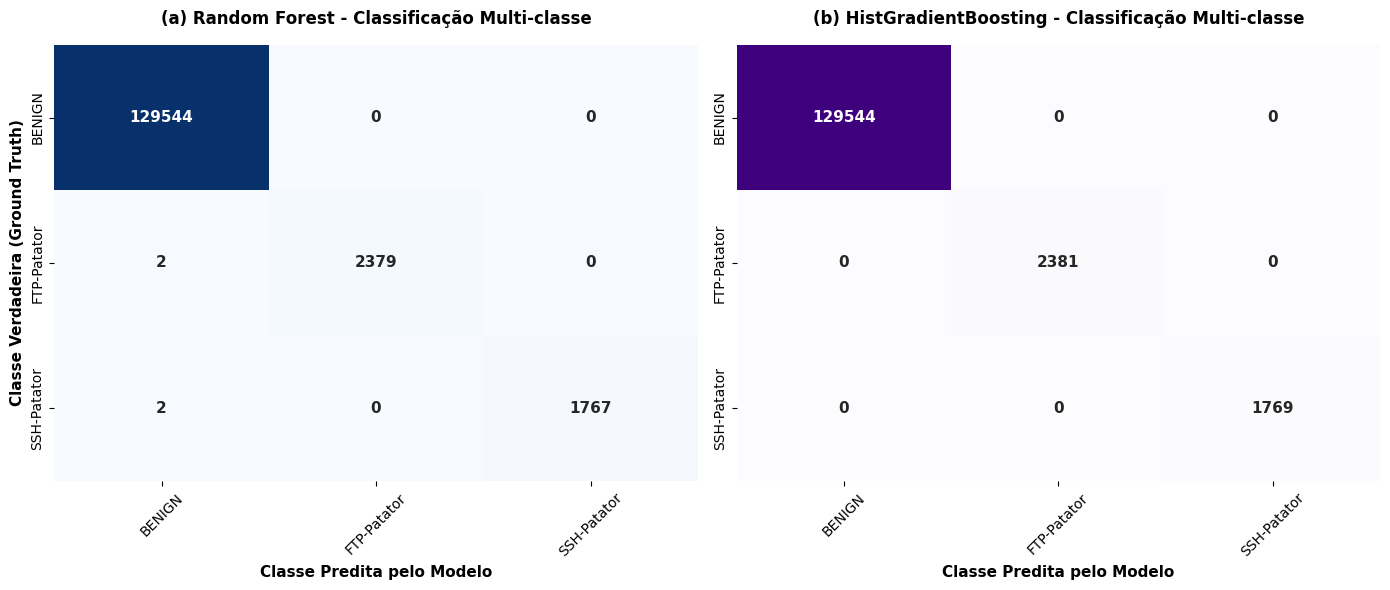

✅ Gráfico duplo exportado com sucesso para: /content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/matrizes_confusao_Terca_ForcaBruta.pdf


In [ ]:
# ==========================================
# MÓDULO 05: AVALIAÇÃO DE RESULTADOS E MATRIZES (IEEE)
# ==========================================
import os
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de Caminhos
NOME_EXPERIMENTO = 'Terca_ForcaBruta'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'
DIRETORIO_GRAFICOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics'
os.makedirs(DIRETORIO_GRAFICOS, exist_ok=True)

print("1. Carregando as predições e os rótulos de teste do Drive...")
# Como limpamos a RAM no Bloco 3, vamos recuperar o y_test e as classes do Label Encoder
label_encoder = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))
nomes_classes = label_encoder.classes_

# Carregando as predições salvas nos módulos 04-A e 04-B
y_pred_rf = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_rf.joblib'))
y_pred_hgb = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_hgb.joblib'))

print("\n" + "="*60)
print(f"📊 RELATÓRIO DE CLASSIFICAÇÃO METODOLÓGICA (TERÇA-FEIRA)")
print("="*60)
print("\n--- PERFORMANCE: RANDOM FOREST (BAGGING) ---")
print(classification_report(y_test, y_pred_rf, target_names=nomes_classes))

print("\n--- PERFORMANCE: HIST GRADIENT BOOSTING (BOOSTING) ---")
print(classification_report(y_test, y_pred_hgb, target_names=nomes_classes))

print("\n2. Renderizando painel de Matrizes de Confusão para o Artigo...")
plt.rcParams['font.family'] = 'sans-serif'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Matriz 1: Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=nomes_classes, yticklabels=nomes_classes, annot_kws={"weight": "bold", "size": 11})
ax1.set_title('(a) Random Forest - Classificação Multi-classe', fontweight='bold', pad=15, fontsize=12)
ax1.set_ylabel('Classe Verdadeira (Ground Truth)', fontweight='bold', fontsize=11)
ax1.set_xlabel('Classe Predita pelo Modelo', fontweight='bold', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# Matriz 2: HistGradientBoosting
cm_hgb = confusion_matrix(y_test, y_pred_hgb)
sns.heatmap(cm_hgb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax2,
            xticklabels=nomes_classes, yticklabels=nomes_classes, annot_kws={"weight": "bold", "size": 11})
ax2.set_title('(b) HistGradientBoosting - Classificação Multi-classe', fontweight='bold', pad=15, fontsize=12)
ax2.set_ylabel('')
ax2.set_xlabel('Classe Predita pelo Modelo', fontweight='bold', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Salvando em PDF Vetorial (Formato exigido pela IEEE/Overleaf para não pixelar)
caminho_saida = os.path.join(DIRETORIO_GRAFICOS, f'matrizes_confusao_{NOME_EXPERIMENTO}.pdf')
plt.savefig(caminho_saida, bbox_inches='tight')
plt.show()

print(f"✅ Gráfico duplo exportado com sucesso para: {caminho_saida}")